In [1]:
import os
import torch
import pandas as pd
import scanpy as sc
from sklearn import metrics
import multiprocessing as mp
import warnings
warnings.filterwarnings("ignore")
from GraphST import GraphST
from lib_3d_OT.utils import *

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [3]:
adata=sc.read_visium('/home/dbj/mouse/DLPFC/DLPFC/151674/')
adata.var_names_make_unique()
truth = pd.read_csv('/home/dbj/mouse/vision/spatial/DLPFC_annotations/151674_truth.csv', sep='\t', index_col=0)

adata.obs['truth'] = truth.iloc[:,0]
adata = adata[~adata.obs['truth'].isna(), :]

In [4]:
model = GraphST.GraphST(adata, device=device)

# train model
adata = model.train()

Begin to train ST data...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [00:09<00:00, 60.84it/s]

Optimization finished for ST data!


In [12]:
clustering(adata, n_clusters=7, radius=50, key='X', method='mclust', refinement=True,random=2023,n_comp=20)

fitting ...
  |======================================================================| 100%


In [13]:
adata.obs['GraphST']=adata.obs['3d-OT']

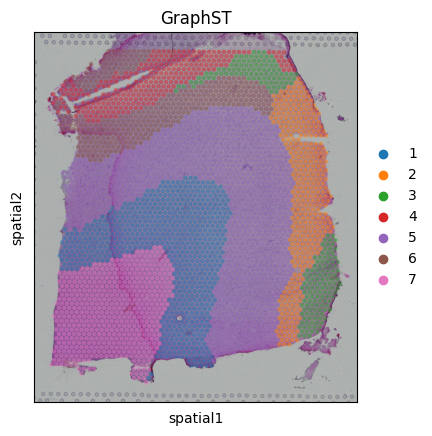

In [14]:
sc.pl.spatial(adata, color='GraphST', img_key='hires', alpha=0.5, size=1.3)

In [15]:
from sklearn.metrics import adjusted_rand_score,normalized_mutual_info_score
ari = adjusted_rand_score(adata.obs['truth'], adata.obs['GraphST'])
nmi = normalized_mutual_info_score(adata.obs['truth'], adata.obs['GraphST'])
ari,nmi

(0.44896002117119094, 0.607378219598957)